# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [1]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ["Right Hand vs Feet MI", "Left Hand vs Right Hand MI", "Five Fingers MI", "Left Hand vs Right Hand vs Feet vs Tongue MI"]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "LeJEPABCI": "LeJEPA",
    "LeJEPAClinical": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM",
    "LUNAModel": "LUNA"
}

In [2]:

from collections.abc import Sequence

from tqdm import tqdm


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def _parse_eval_noise(data: dict) -> dict:
    """Parse evaluation noise metadata with backward compatibility."""
    eval_noise = data.get("eval_noise") or {}
    tag = eval_noise.get("tag", "clean")
    snr_db = eval_noise.get("snr_db")
    noise_types = eval_noise.get("noise_types") or []
    is_clean = snr_db is None
    return {
        "noise_tag": tag,
        "noise_snr_db": snr_db,
        "noise_types": noise_types,
        "is_clean": is_clean,
    }


def load_results(results_dir="results/raw"):
    """Load all results JSON files into a DataFrame."""
    records = []

    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    for filepath in tqdm(json_files):
        try:
            with open(filepath) as f:
                data = json.load(f)

            task_name = data.get("task_name", "unknown")
            model_names = data.get("models_names", ["unknown"])
            percentage = data.get("data_percentage", 1.0)
            linear_probe = data.get("linear_probe", False)
            timestamp = data.get("timestamp", "")
            data_stats = data.get("data_stats", {})
            seed = data.get("seed", 42)  # Add this line

            ckpt_id = data.get("checkpoint_id", {})
            step = 'None'
            result_prefix = data.get("result_prefix", "").replace('lejepa', '')
            if ckpt_id:
                step = ckpt_id #int(ckpt_id.split('step_')[-1]) if 'last' not in ckpt_id else 

            noise_info = _parse_eval_noise(data)
            probe_type = data.get("probe_type", "linear") #linear or attn

            y_test = data.get("y_test", [[]])
            results = data.get("results", [[]])

            # Process each model's results
            for i, model_name in enumerate(model_names):
                try:
                    # Get predictions for this model (handle nested structure)
                    if i < len(results):
                        y_pred = results[i] if isinstance(results[i], list) else results
                        y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                    else:
                        y_pred = results[0] if results else []
                        y_true = y_test[0] if y_test else []

                    # Compute metrics
                    metrics = compute_metrics(y_true, y_pred)

                    # Clean up model name for display
                    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                    record = {
                        "task": task_name,
                        "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                        "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                        "model": model_name + result_prefix,
                        "model_display": display_name + result_prefix,
                        "percentage": percentage,
                        "linear_probe": linear_probe,
                        "timestamp": timestamp,
                        # "total_samples": data_stats.get("total_samples", 0),
                        "file": os.path.basename(filepath),
                        "step": step,
                        "probe_type": probe_type,
                        **noise_info,
                        **metrics,
                        "seed": seed,
                    }
                    records.append(record)

                except Exception:
                    raise

        except Exception:
            print(f"Error processing file: {filepath}")
            # raise

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df


In [3]:
df_all = load_results("results_rebuttal/rerunning_laya/raw")


Found 2483 result files


 60%|█████▉    | 1478/2483 [09:44<02:13,  7.55it/s]  

Error processing file: results_rebuttal/rerunning_laya/raw/laya-small-matched_multiclass_artifact_clinical_LeJEPAClinical_ckpt_last_LP_20260324_194716.json


 61%|██████    | 1508/2483 [09:48<01:23, 11.71it/s]

Error processing file: results_rebuttal/rerunning_laya/raw/laya-b-50k-02sig_seizure_clinical_LeJEPAClinical_ckpt_epoch_0_step_30000_LP_20260326_140326.json


100%|██████████| 2483/2483 [13:43<00:00,  3.01it/s]

Loaded 2481 experiment results


In [4]:
include_baselines = False

In [5]:
df_all['model_display'] = df_all['model_display'].str.replace('lejeba', '')
df_all['model_display'].unique()

array(['LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred',
       'LeJEPA_base_global_projv2_02sig_FULL_v2',
       'LeJEPAlaya-small-matched',
       'LeJEPA_base_global_projv2_02sig_FULL_v0',
       'LeJEPAlaya-b-50k-02sig', 'LeJEPAlaya-s-nostopgrad',
       'LeJEPA_base_global_projv2_05sig_FULL_v3',
       'LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-b-20k-02sig',
       'LeJEPAlaya-mae', 'LeJEPAlaya-b-nostopgrad',
       'LeJEPAlaya-b-smallmatched',
       'LeJEPA_base_global_projv2_smallds-15k'], dtype=object)

In [6]:
df_all.groupby(['model_display', 'step']).size()

model_display                                        step              
LeJEPA_base_global_projv2_02sig_FULL_v0              epoch_0_step_10000    69
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_30000    70
                                                     last                  70
LeJEPA_base_global_projv2_02sig_FULL_v2              last                  67
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred  epoch_0_step_10000    70
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_30000    70
                                                     last                  70
LeJEPA_base_global_projv2_05sig_FULL_v3              epoch_0_step_10000    70
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_3000

In [7]:

# Load results (clean + noise-aware)
if include_baselines:
    df_labram = pd.read_csv('labram_results_all.csv', index_col = None)
    df_labram['noise_types'] = df_labram['noise_types'].apply(lambda x: eval(x))

    df_luna = pd.read_csv('luna_results.csv', index_col = 0)

    df_combined = pd.concat([df_all, df_labram, df_luna])
    df_combined['step'] = df_combined['step'].fillna('last')
    df_combined['is_clean'] = df_combined['is_clean'].fillna(True)
else:
    df_combined = df_all.copy()


df_combined['probe_type'] = df_combined['probe_type'].fillna('linear')


df_clean = df_combined.copy()
df_noise = df_combined.copy()

if len(df_combined) > 0:
    # Normalize noise types for grouping/labels
    if "noise_types" in df_combined.columns:
        df_combined["noise_types_str"] = df_combined["noise_types"].apply(
            lambda x: "+".join(x) if isinstance(x, (list, tuple)) else ""
        )
    else:
        df_combined["noise_types_str"] = ""

    df_clean = df_combined[df_combined["is_clean"]].copy() if "is_clean" in df_combined.columns else df_combined.copy()
    df_noise = df_combined[~df_combined["is_clean"]].copy() if "is_clean" in df_combined.columns else df_combined.iloc[0:0].copy()
    

    # IMPORTANT: all existing plots below should use clean-only results
    df = df_clean
    df = df[df['probe_type'] == 'linear']
    # df = df[df['step'] == 'epoch_0_step_10000']
    

    print(f"Clean results: {len(df_clean)} rows")
    print(f"Noise results: {len(df_noise)} rows")
    print(f"Unique tasks (clean): {df['task'].nunique()}")
    print(f"Unique models (clean): {df['model_display'].nunique()}")
    print(f"Data percentages (clean): {sorted(df['percentage'].unique())}")
    print(f"Tasks (clean): {df['task'].unique().tolist()}")
    print(f"Models (clean): {df['model_display'].unique().tolist()}")
    print(f"Steps (clean): {df['step'].unique().tolist()}")
else:
    print("No results found. Run experiments first with run_experiments.py")


Clean results: 2481 rows
Noise results: 0 rows
Unique tasks (clean): 14
Unique models (clean): 13
Data percentages (clean): [1.0]
Tasks (clean): ['Five Fingers MI', 'ocd_clinical', 'schizophrenia_clinical', 'binary_artifact_clinical', 'Left Hand vs Right Hand MI', 'Left Hand vs Right Hand vs Feet vs Tongue MI', 'multiclass_artifact_clinical', 'epilepsy_clinical', 'Right Hand vs Feet MI', 'mtbi_clinical', 'sleep_stages_clinical', 'seizure_clinical', 'abnormal_clinical', 'parkinsons_clinical']
Models (clean): ['LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred', 'LeJEPA_base_global_projv2_02sig_FULL_v2', 'LeJEPAlaya-small-matched', 'LeJEPA_base_global_projv2_02sig_FULL_v0', 'LeJEPAlaya-b-50k-02sig', 'LeJEPAlaya-s-nostopgrad', 'LeJEPA_base_global_projv2_05sig_FULL_v3', 'LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-b-20k-02sig', 'LeJEPAlaya-mae', 'LeJEPAlaya-b-nostopgrad', 'LeJEPAlaya-b-smallmatched', 'LeJEPA_base_global_projv2_smallds-15k']
Steps (clean): ['last', 'epoch_0_step_30000

In [8]:
# Drop duplicates (exclude unhashable list columns like noise_types)
unhashable_cols = {"noise_types"}
exclude_cols = {"timestamp", "file"} | unhashable_cols

subset_cols = [c for c in df.columns if c not in exclude_cols]
df = df.drop_duplicates(subset=subset_cols)

print(f"After deduplication: {len(df)} rows")
print(f"Models (clean): {df['model_display'].unique().tolist()}")


After deduplication: 2481 rows
Models (clean): ['LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred', 'LeJEPA_base_global_projv2_02sig_FULL_v2', 'LeJEPAlaya-small-matched', 'LeJEPA_base_global_projv2_02sig_FULL_v0', 'LeJEPAlaya-b-50k-02sig', 'LeJEPAlaya-s-nostopgrad', 'LeJEPA_base_global_projv2_05sig_FULL_v3', 'LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-b-20k-02sig', 'LeJEPAlaya-mae', 'LeJEPAlaya-b-nostopgrad', 'LeJEPAlaya-b-smallmatched', 'LeJEPA_base_global_projv2_smallds-15k']


In [9]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,file,step,...,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,seed,noise_types_str
0,Five Fingers MI,Five Fingers MI,BCI,LeJEPABCI_base_global_projv2_05sig_FULL_v2_big...,LeJEPA_base_global_projv2_05sig_FULL_v2_bigger...,1.0,True,20260318_065051,lejepa_base_global_projv2_05sig_FULL_v2_bigger...,last,...,None,[],True,0.223802,0.218009,0.205261,0.202398,0.023850,789,
1,ocd_clinical,ocd_clinical,Clinical,LeJEPAClinical_base_global_projv2_02sig_FULL_v2,LeJEPA_base_global_projv2_02sig_FULL_v2,1.0,True,20260317_204248,lejepa_base_global_projv2_02sig_FULL_v2_ocd_cl...,last,...,None,[],True,0.818182,0.800000,0.808442,0.803571,0.620690,456,
2,schizophrenia_clinical,schizophrenia_clinical,Clinical,LeJEPAClinicallaya-small-matched,LeJEPAlaya-small-matched,1.0,True,20260324_190702,laya-small-matched_schizophrenia_clinical_LeJE...,epoch_0_step_30000,...,None,[],True,0.538462,0.547619,0.532967,0.535714,0.093023,456,
3,binary_artifact_clinical,binary_artifact_clinical,Clinical,LeJEPAClinical_base_global_projv2_02sig_FULL_v0,LeJEPA_base_global_projv2_02sig_FULL_v0,1.0,True,20260317_190052,lejepa_base_global_projv2_02sig_FULL_v0_binary...,last,...,None,[],True,0.673996,0.669294,0.677851,0.662610,0.327911,789,
4,ocd_clinical,ocd_clinical,Clinical,LeJEPAClinicallaya-b-50k-02sig,LeJEPAlaya-b-50k-02sig,1.0,True,20260326_115949,laya-b-50k-02sig_ocd_clinical_LeJEPAClinical_c...,epoch_0_step_10000,...,None,[],True,0.636364,0.633333,0.636364,0.633333,0.266667,101,
5,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,LeJEPABCIlaya-s-nostopgrad,LeJEPAlaya-s-nostopgrad,1.0,True,20260326_104805,laya-s-nostopgrad_Left Hand vs Right Hand MI_L...,last,...,None,[],True,0.518262,0.518140,0.517745,0.517682,0.036288,789,
6,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,BCI,LeJEPABCI_base_global_projv2_05sig_FULL_v2_big...,LeJEPA_base_global_projv2_05sig_FULL_v2_bigger...,1.0,True,20260318_030919,lejepa_base_global_projv2_05sig_FULL_v2_bigger...,epoch_0_step_10000,...,None,[],True,0.291924,0.289747,0.275261,0.274269,0.053427,42,
7,multiclass_artifact_clinical,multiclass_artifact_clinical,Clinical,LeJEPAClinicallaya-b-50k-02sig,LeJEPAlaya-b-50k-02sig,1.0,True,20260326_134309,laya-b-50k-02sig_multiclass_artifact_clinical_...,epoch_0_step_30000,...,None,[],True,0.454792,0.270181,0.516182,0.257327,0.199618,101,
8,epilepsy_clinical,epilepsy_clinical,Clinical,LeJEPAClinicallaya-b-50k-02sig,LeJEPAlaya-b-50k-02sig,1.0,True,20260326_124048,laya-b-50k-02sig_epilepsy_clinical_LeJEPAClini...,epoch_0_step_20000,...,None,[],True,0.652956,0.615875,0.658553,0.610818,0.223300,456,
9,binary_artifact_clinical,binary_artifact_clinical,Clinical,LeJEPAClinical_base_global_projv2_02sig_FULL_v2,LeJEPA_base_global_projv2_02sig_FULL_v2,1.0,True,20260317_202119,lejepa_base_global_projv2_02sig_FULL_v2_binary...,last,...,None,[],True,0.655516,0.648120,0.659337,0.642692,0.287737,789,


In [10]:
df.groupby(['model_display', 'step']).size() #, 'task'

model_display                                        step              
LeJEPA_base_global_projv2_02sig_FULL_v0              epoch_0_step_10000    69
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_30000    70
                                                     last                  70
LeJEPA_base_global_projv2_02sig_FULL_v2              last                  67
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred  epoch_0_step_10000    70
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_30000    70
                                                     last                  70
LeJEPA_base_global_projv2_05sig_FULL_v3              epoch_0_step_10000    70
                                                     epoch_0_step_20000    70
                                                     epoch_0_step_3000

## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [11]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [12]:
model_colors = {
    "Laya": "#1473d3",
    "Laya-S": "#3aacce",
    # "Laya-S_20k": "#4ece3a",

    'LaBraM': "#c51a1a"
}

In [13]:
df_noise['model_display'].unique()

array([], dtype=object)

In [14]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = model_colors
    
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            # if 'LUNA' in model: 
            #     continue
            # if '20k' in model:
            #     continue
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        #logscale x
        # ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

In [15]:
# # Plot grid view
# if len(df) > 0 and df["task"].nunique() > 1:
#     plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [16]:
# def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
#     """Create pivot table: tasks (rows) x models (columns)."""
#     subset = df[df["percentage"] == percentage].copy()

#     if len(subset) == 0:
#         print(f"No data for percentage={percentage}")
#         return None

#     table = subset.pivot_table(
#         values=metric,
#         index="task_display",
#         columns=["model_display", 'step'],
#         aggfunc="mean"
#     )

#     # Add mean row
#     table.loc["Mean"] = table.mean(axis=0)

#     # Sort by mean performance (descending)
#     table = table.loc[:, table.loc["Mean"].sort_values(ascending=False).index]

#     os.makedirs("tables/", exist_ok=True)
#     table.to_csv(f"tables/model_comparison_{metric}.csv")
#     print(f"Saved model comparison table to tables/model_comparison_{metric}.csv")

#     return table.round(3)



def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy", format_stats=False):
    """Create pivot table: tasks (rows) x models/steps (columns).

    If format_stats=True, returns strings like '0.812 ± 0.034'.
    Otherwise returns the mean table for downstream numeric use.
    """
    subset = df[df["percentage"] == percentage].copy()

    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None

    group_cols = ["task_display", "model_display", "step"]
    stats = (
        subset.groupby(group_cols)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    mean_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="mean",
    )

    std_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="std",
    )

    count_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="count",
    )

    # Add mean row using numeric means only
    mean_table.loc["Mean"] = mean_table.mean(axis=0)
    std_table.loc["Mean"] = std_table.mean(axis=0)
    count_table.loc["Mean"] = count_table.sum(axis=0)

    # Sort columns by overall mean performance
    sorted_cols = mean_table.loc["Mean"].sort_values(ascending=False).index
    mean_table = mean_table.loc[:, sorted_cols]
    std_table = std_table.loc[:, sorted_cols]
    count_table = count_table.loc[:, sorted_cols]

    os.makedirs("tables/", exist_ok=True)
    mean_table.to_csv(f"tables/model_comparison_{metric}_mean.csv")
    std_table.to_csv(f"tables/model_comparison_{metric}_std.csv")

    if not format_stats:
        print(f"Saved numeric tables to tables/model_comparison_{metric}_mean.csv and _std.csv")
        return mean_table.round(3)

    formatted_table = mean_table.copy().astype(object)
    for row in mean_table.index:
        for col in mean_table.columns:
            mean_val = mean_table.loc[row, col]
            std_val = std_table.loc[row, col]
            n_val = count_table.loc[row, col]

            if pd.isna(mean_val):
                formatted_table.loc[row, col] = ""
            elif row == "Mean":
                formatted_table.loc[row, col] = f"{mean_val:.3f}"
            elif pd.isna(std_val) or n_val <= 1:
                formatted_table.loc[row, col] = f"{mean_val:.3f}"
            else:
                formatted_table.loc[row, col] = f"{mean_val:.3f} ± {std_val:.3f}"

    # formatted_table.to_csv(f"tables/model_comparison_{metric}_formatted.csv")
    # print(f"Saved formatted table to tables/model_comparison_{metric}_formatted.csv")
    return formatted_table

In [17]:
TASK_DISPLAY = {
    "Five Fingers MI": "5-Finger MI",
    "Left Hand vs Right Hand MI": "LH vs RH MI",
    "Left Hand vs Right Hand vs Feet vs Tongue MI": "4-Class MI",
    "Right Hand vs Feet MI": "RH vs Feet MI",
    "abnormal": "Abnormal",
    "binary artifact": "Artifact (Binary)",
    "multiclass artifact": "Artifact (Multiclass)",
    "epilepsy": "Epilepsy",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "seizure": "Seizure",
    "sleep stages": "Sleep Stages",
}



In [18]:
metrics = ["accuracy", "balanced_accuracy", "f1_weighted", "f1_macro", "kappa"]

if len(df) > 0:
    for metric in metrics:
        table_num = model_comparison_table(df, percentage=1.0, metric=metric, format_stats=False)
        table_fmt = model_comparison_table(df, percentage=1.0, metric=metric, format_stats=True)

        if table_num is None or len(table_num) == 0:
            continue

        print(f"Model Comparison (100% training data, {metric.replace('_', ' ').title()}):")
        display(table_fmt)

Saved numeric tables to tables/model_comparison_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Accuracy):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.212 ± 0.011   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.275 ± 0.005   
Right Hand vs Feet MI                                            0.585 ± 0.002   
abnormal_clinical                                                0.802 ± 0.007   
binary_artifact_clinical                                         0.723 ± 0.001   
epilepsy_clinical                                                0.702 ± 0.013   
mtbi_clinical                                                    0.743 ± 0.016   
multiclass_artifact_clinical                                     0.525 ± 0.014   
ocd_clinical                                                     0.618 ± 0.149   
parkinsons_clinical                                              0.724 ± 0.018   
schizophrenia_clinical                                           0.477 ± 0.064   
seizure_clinical                                                 0.856 ± 0.021   
sleep_stages_clinical                                            0.241 ± 0.000   
Mean                                                                     0.571   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.206 ± 0.003   
Left Hand vs Right Hand MI                            0.506 ± 0.004   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.290 ± 0.007   
Right Hand vs Feet MI                                 0.573 ± 0.002   
abnormal_clinical                                     0.785 ± 0.008   
binary_artifact_clinical                              0.745 ± 0.002   
epilepsy_clinical                                     0.661 ± 0.009   
mtbi_clinical                                         0.836 ± 0.048   
multiclass_artifact_clinical                          0.555 ± 0.017   
ocd_clinical                                          0.564 ± 0.041   
parkinsons_clinical                                   0.677 ± 0.021   
schizophrenia_clinical                                0.492 ± 0.042   
seizure_clinical                                      0.854 ± 0.025   
sleep_stages_clinical                                 0.238 ± 0.000   
Mean                                                          0.570   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.212 ± 0.011   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.275 ± 0.005   
Right Hand vs Feet MI                                            0.585 ± 0.002   
abnormal_clinical                                                0.793 ± 0.011   
binary_artifact_clinical                                         0.723 ± 0.002   
epilepsy_clinical                                                0.694 ± 0.012   
mtbi_clinical                                                    0.643 ± 0.076   
multiclass_artifact_clinical                                     0.512 ± 0.027   
ocd_clinical                                                     0.691 ± 0.081   
parkinsons_clinical                                              0.673 ± 0.007   
schizophrenia_clinical                                           0.538 ± 0.000   
seizure_clinic

Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Balanced Accuracy):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.210 ± 0.007   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.273 ± 0.005   
Right Hand vs Feet MI                                            0.586 ± 0.002   
abnormal_clinical                                                0.798 ± 0.007   
binary_artifact_clinical                                         0.716 ± 0.001   
epilepsy_clinical                                                0.657 ± 0.023   
mtbi_clinical                                                    0.699 ± 0.030   
multiclass_artifact_clinical                                     0.375 ± 0.002   
ocd_clinical                                                     0.627 ± 0.144   
parkinsons_clinical                                              0.708 ± 0.012   
schizophrenia_clinical                                           0.479 ± 0.060   
seizure_clinical                                                 0.786 ± 0.014   
sleep_stages_clinical                                            0.185 ± 0.000   
Mean                                                                     0.543   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.205 ± 0.005   
Left Hand vs Right Hand MI                            0.507 ± 0.004   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.288 ± 0.007   
Right Hand vs Feet MI                                 0.578 ± 0.002   
abnormal_clinical                                     0.778 ± 0.006   
binary_artifact_clinical                              0.737 ± 0.001   
epilepsy_clinical                                     0.596 ± 0.012   
mtbi_clinical                                         0.815 ± 0.048   
multiclass_artifact_clinical                          0.382 ± 0.008   
ocd_clinical                                          0.567 ± 0.037   
parkinsons_clinical                                   0.683 ± 0.012   
schizophrenia_clinical                                0.502 ± 0.042   
seizure_clinical                                      0.723 ± 0.005   
sleep_stages_clinical                                 0.183 ± 0.001   
Mean                                                          0.539   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.210 ± 0.007   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.273 ± 0.005   
Right Hand vs Feet MI                                            0.586 ± 0.002   
abnormal_clinical                                                0.788 ± 0.012   
binary_artifact_clinical                                         0.715 ± 0.001   
epilepsy_clinical                                                0.594 ± 0.029   
mtbi_clinical                                                    0.608 ± 0.043   
multiclass_artifact_clinical                                     0.369 ± 0.005   
ocd_clinical                                                     0.683 ± 0.075   
parkinsons_clinical                                              0.655 ± 0.009   
schizophrenia_clinical                                           0.533 ± 0.005   
seizure_clinic

Saved numeric tables to tables/model_comparison_f1_weighted_mean.csv and _std.csv
Model Comparison (100% training data, F1 Weighted):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.190 ± 0.027   
Left Hand vs Right Hand MI                                       0.507 ± 0.005   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.267 ± 0.003   
Right Hand vs Feet MI                                            0.587 ± 0.002   
abnormal_clinical                                                0.801 ± 0.007   
binary_artifact_clinical                                         0.725 ± 0.001   
epilepsy_clinical                                                0.703 ± 0.014   
mtbi_clinical                                                    0.738 ± 0.012   
multiclass_artifact_clinical                                     0.568 ± 0.012   
ocd_clinical                                                     0.607 ± 0.160   
parkinsons_clinical                                              0.726 ± 0.016   
schizophrenia_clinical                                           0.475 ± 0.067   
seizure_clinical                                                 0.919 ± 0.012   
sleep_stages_clinical                                            0.258 ± 0.000   
Mean                                                                     0.577   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.180 ± 0.024   
Left Hand vs Right Hand MI                            0.489 ± 0.034   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.276 ± 0.009   
Right Hand vs Feet MI                                 0.574 ± 0.002   
abnormal_clinical                                     0.783 ± 0.007   
binary_artifact_clinical                              0.747 ± 0.002   
epilepsy_clinical                                     0.656 ± 0.003   
mtbi_clinical                                         0.836 ± 0.046   
multiclass_artifact_clinical                          0.596 ± 0.014   
ocd_clinical                                          0.564 ± 0.041   
parkinsons_clinical                                   0.682 ± 0.021   
schizophrenia_clinical                                0.476 ± 0.059   
seizure_clinical                                      0.918 ± 0.015   
sleep_stages_clinical                                 0.253 ± 0.000   
Mean                                                          0.574   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.190 ± 0.027   
Left Hand vs Right Hand MI                                       0.507 ± 0.005   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.267 ± 0.003   
Right Hand vs Feet MI                                            0.587 ± 0.002   
abnormal_clinical                                                0.792 ± 0.011   
binary_artifact_clinical                                         0.725 ± 0.002   
epilepsy_clinical                                                0.670 ± 0.021   
mtbi_clinical                                                    0.631 ± 0.057   
multiclass_artifact_clinical                                     0.557 ± 0.027   
ocd_clinical                                                     0.687 ± 0.079   
parkinsons_clinical                                              0.676 ± 0.006   
schizophrenia_clinical                                           0.535 ± 0.008   
seizure_clinic

Saved numeric tables to tables/model_comparison_f1_macro_mean.csv and _std.csv
Model Comparison (100% training data, F1 Macro):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.189 ± 0.030   
Left Hand vs Right Hand MI                                       0.507 ± 0.005   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.266 ± 0.003   
Right Hand vs Feet MI                                            0.583 ± 0.002   
abnormal_clinical                                                0.799 ± 0.007   
binary_artifact_clinical                                         0.711 ± 0.001   
epilepsy_clinical                                                0.655 ± 0.020   
mtbi_clinical                                                    0.698 ± 0.017   
multiclass_artifact_clinical                                     0.321 ± 0.005   
ocd_clinical                                                     0.609 ± 0.155   
parkinsons_clinical                                              0.705 ± 0.015   
schizophrenia_clinical                                           0.475 ± 0.064   
seizure_clinical                                                 0.476 ± 0.007   
sleep_stages_clinical                                            0.173 ± 0.000   
Mean                                                                     0.512   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.179 ± 0.025   
Left Hand vs Right Hand MI                            0.489 ± 0.033   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.275 ± 0.009   
Right Hand vs Feet MI                                 0.572 ± 0.002   
abnormal_clinical                                     0.780 ± 0.007   
binary_artifact_clinical                              0.733 ± 0.001   
epilepsy_clinical                                     0.597 ± 0.009   
mtbi_clinical                                         0.813 ± 0.051   
multiclass_artifact_clinical                          0.328 ± 0.007   
ocd_clinical                                          0.563 ± 0.039   
parkinsons_clinical                                   0.666 ± 0.017   
schizophrenia_clinical                                0.480 ± 0.056   
seizure_clinical                                      0.473 ± 0.008   
sleep_stages_clinical                                 0.170 ± 0.000   
Mean                                                          0.508   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.189 ± 0.030   
Left Hand vs Right Hand MI                                       0.507 ± 0.005   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.266 ± 0.003   
Right Hand vs Feet MI                                            0.583 ± 0.002   
abnormal_clinical                                                0.790 ± 0.012   
binary_artifact_clinical                                         0.710 ± 0.002   
epilepsy_clinical                                                0.596 ± 0.032   
mtbi_clinical                                                    0.585 ± 0.041   
multiclass_artifact_clinical                                     0.315 ± 0.008   
ocd_clinical                                                     0.683 ± 0.077   
parkinsons_clinical                                              0.651 ± 0.007   
schizophrenia_clinical                                           0.531 ± 0.010   
seizure_clinic

Saved numeric tables to tables/model_comparison_kappa_mean.csv and _std.csv
Model Comparison (100% training data, Kappa):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.013 ± 0.008   
Left Hand vs Right Hand MI                                       0.020 ± 0.006   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.032 ± 0.007   
Right Hand vs Feet MI                                            0.169 ± 0.003   
abnormal_clinical                                                0.599 ± 0.014   
binary_artifact_clinical                                         0.423 ± 0.002   
epilepsy_clinical                                                0.311 ± 0.040   
mtbi_clinical                                                    0.402 ± 0.030   
multiclass_artifact_clinical                                     0.311 ± 0.010   
ocd_clinical                                                     0.250 ± 0.279   
parkinsons_clinical                                              0.410 ± 0.029   
schizophrenia_clinical                                          -0.042 ± 0.118   
seizure_clinical                                                 0.024 ± 0.002   
sleep_stages_clinical                                            0.024 ± 0.000   
Mean                                                                     0.210   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.007 ± 0.006   
Left Hand vs Right Hand MI                            0.013 ± 0.008   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.051 ± 0.009   
Right Hand vs Feet MI                                 0.152 ± 0.004   
abnormal_clinical                                     0.562 ± 0.015   
binary_artifact_clinical                              0.467 ± 0.002   
epilepsy_clinical                                     0.196 ± 0.017   
mtbi_clinical                                         0.627 ± 0.103   
multiclass_artifact_clinical                          0.334 ± 0.015   
ocd_clinical                                          0.132 ± 0.075   
parkinsons_clinical                                   0.343 ± 0.027   
schizophrenia_clinical                                0.004 ± 0.083   
seizure_clinical                                      0.019 ± 0.002   
sleep_stages_clinical                                 0.020 ± 0.001   
Mean                                                          0.209   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.013 ± 0.008   
Left Hand vs Right Hand MI                                       0.020 ± 0.006   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.032 ± 0.007   
Right Hand vs Feet MI                                            0.169 ± 0.003   
abnormal_clinical                                                0.580 ± 0.023   
binary_artifact_clinical                                         0.421 ± 0.003   
epilepsy_clinical                                                0.208 ± 0.056   
mtbi_clinical                                                    0.210 ± 0.073   
multiclass_artifact_clinical                                     0.294 ± 0.017   
ocd_clinical                                                     0.372 ± 0.153   
parkinsons_clinical                                              0.304 ± 0.015   
schizophrenia_clinical                                           0.067 ± 0.010   
seizure_clinic

In [19]:
# Model comparison tables for each metric (with LaTeX export)
metrics = ["accuracy", "balanced_accuracy", "f1_weighted", "f1_macro", "kappa"]

if len(df) > 0:
    for metric in metrics:
        table = model_comparison_table(df, percentage=1.0, metric=metric)
        # rename LUNAModel -> LUNA (if needed)
        table = table.rename(columns={"LUNAModel": "LUNA"})

        # enforce column order
        # desired_order = ["LaBraM", "LUNA", "Laya-S", "Laya","Laya-V2-05sig", "Laya-V2-05sig_longer", "Laya-vitb-05sig"] # add more if needed
        # cols = [c for c in desired_order if c in table.columns]# + [c for c in table.columns if c not in desired_order]
        # table = table[cols]

        
        if table is None or len(table) == 0:
            continue
        print(f"Model Comparison (100% training data, {metric.replace('_', ' ').title()}):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))
        

        caption = f"Linear probe performance on EEG-Bench ({metric})."
        label = f"tab:eegebench_{metric}"

        # clean table for LaTeX
        table = table.copy()
        table.index.name = None
        table.columns.name = None
        table.index = (
            table.index
            .str.replace("_clinical", "", regex=False)
            .str.replace("_", " ", regex=False)
        )
        # apply after your underscore cleanup
        table.index = table.index.to_series().map(lambda x: TASK_DISPLAY.get(x, x)).values


        latex_tab = table.to_latex(
            index=True,
            float_format="%.3f",
            escape=False,
            column_format="l" + "r" * len(table.columns),
            caption=caption,
            label=label,
        )

        latex_full = "\\begin{table}[t]\n\\centering\n"
        latex_full += latex_tab.replace("\\begin{table}", "").replace("\\end{table}", "")
        latex_full = latex_full.replace("\\begin{tabular}", "\\resizebox{\\columnwidth}{!}{%\n\\begin{tabular}")
        latex_full = latex_full.replace("\\end{tabular}", "\\end{tabular}\n}")
        latex_full += "\\end{table}\n"

        # with open(f"tables/model_comparison_{metric}.tex", "w") as f:
        #     f.write(latex_full)


else:
    print("No data available for model comparison tables.")


Saved numeric tables to tables/model_comparison_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Accuracy):


Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Balanced Accuracy):


Saved numeric tables to tables/model_comparison_f1_weighted_mean.csv and _std.csv
Model Comparison (100% training data, F1 Weighted):


Saved numeric tables to tables/model_comparison_f1_macro_mean.csv and _std.csv
Model Comparison (100% training data, F1 Macro):


Saved numeric tables to tables/model_comparison_kappa_mean.csv and _std.csv
Model Comparison (100% training data, Kappa):


In [20]:
# (Deprecated) Single-metric table generation moved to the loop above.


In [21]:
def plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv


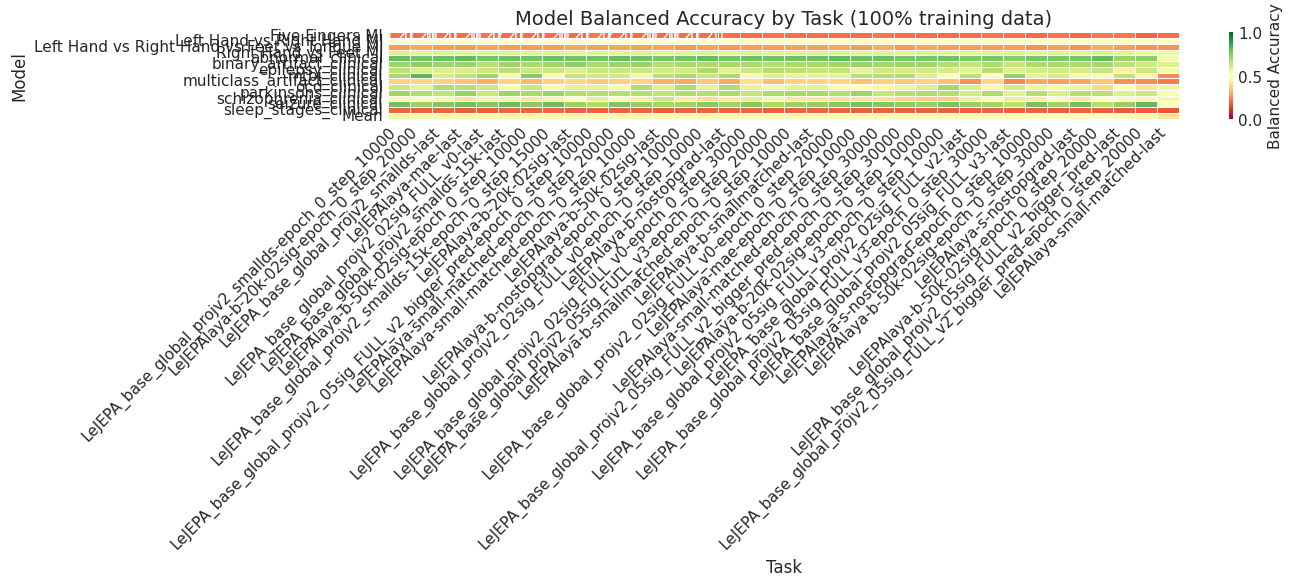

Saved to results/comparison_heatmap_balanced_accuracy.png


In [22]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [23]:
def best_model_per_task(df, percentage=1.0, metric="balanced_accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    max_acc = subset.groupby('task')['balanced_accuracy'].transform('max')
    best = subset[subset['balanced_accuracy'] == max_acc][['task', 'task_display', 'model_display', 'balanced_accuracy']].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [24]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_balanced_accuracy
1245,Five Fingers MI,Five Fingers MI,LeJEPAlaya-b-50k-02sig,0.237473
2153,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LeJEPAlaya-s-nostopgrad,0.518140
5,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LeJEPAlaya-s-nostopgrad,0.518140
1093,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LeJEPAlaya-small-matched,0.303992
108,Right Hand vs Feet MI,Right Hand vs Feet MI,LeJEPAlaya-b-50k-02sig,0.594502
2471,abnormal_clinical,abnormal_clinical,LeJEPA_base_global_projv2_02sig_FULL_v0,0.814921
233,binary_artifact_clinical,binary_artifact_clinical,LeJEPAlaya-b-20k-02sig,0.739034
2206,binary_artifact_clinical,binary_artifact_clinical,LeJEPAlaya-b-20k-02sig,0.739034
1073,epilepsy_clinical,epilepsy_clinical,LeJEPA_base_global_projv2_02sig_FULL_v0,0.721941
313,mtbi_clinical,mtbi_clinical,LeJEPAlaya-b-20k-02sig,0.836257


In [25]:
#what model has the most bests? 
w = best['model_display'].value_counts()
w

model_display
LeJEPAlaya-b-20k-02sig                                 7
LeJEPAlaya-b-50k-02sig                                 3
LeJEPA_base_global_projv2_02sig_FULL_v0                3
LeJEPAlaya-s-nostopgrad                                2
LeJEPAlaya-small-matched                               2
LeJEPAlaya-b-nostopgrad                                2
LeJEPA_base_global_projv2_05sig_FULL_v3                1
LeJEPAlaya-mae                                         1
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_pred    1
LeJEPA_base_global_projv2_smallds                      1
Name: count, dtype: int64

In [26]:
# def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
#     """Compute average rank of each model across tasks."""
#     subset = df[df["percentage"] == percentage].copy()
    
#     if len(subset) == 0:
#         return None
    
#     # Compute rank per task (1 = best)
#     subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
#     # Average rank per model
#     rankings = subset.groupby("model_display").agg({
#         "rank": "mean",
#         metric: "mean"
#     }).round(2)
    
#     rankings = rankings.sort_values("rank")
#     rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
#     return rankings

def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
    """Compute average rank of each model across tasks (only tasks with 2+ models)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Only include tasks that have multiple models
    task_model_counts = subset.groupby("task")["model_display"].nunique()
    tasks_with_multiple_models = task_model_counts[task_model_counts > 1].index
    print(len(tasks_with_multiple_models))
    subset = subset[subset["task"].isin(tasks_with_multiple_models)]
    
    if len(subset) == 0:
        print("No tasks with multiple models to rank")
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [27]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

14
Model Rankings (lower rank = better)


,Avg Rank,Avg Balanced_Accuracy
model_display,,
LeJEPA_base_global_projv2_smallds,55.33,0.54
LeJEPA_base_global_projv2_smallds-15k,59.11,0.53
LeJEPAlaya-b-20k-02sig,75.57,0.53
LeJEPAlaya-b-smallmatched,77.41,0.52
LeJEPA_base_global_projv2_02sig_FULL_v0,78.28,0.52
LeJEPAlaya-mae,83.94,0.53
LeJEPAlaya-small-matched,92.54,0.50
LeJEPAlaya-b-50k-02sig,93.64,0.51
LeJEPAlaya-b-nostopgrad,101.32,0.52


## 5. BCI vs Clinical Comparison

In [30]:
df.groupby('task')['task_type'].first()

task
Five Fingers MI                                      BCI
Left Hand vs Right Hand MI                           BCI
Left Hand vs Right Hand vs Feet vs Tongue MI         BCI
Right Hand vs Feet MI                                BCI
abnormal_clinical                               Clinical
binary_artifact_clinical                        Clinical
epilepsy_clinical                               Clinical
mtbi_clinical                                   Clinical
multiclass_artifact_clinical                    Clinical
ocd_clinical                                    Clinical
parkinsons_clinical                             Clinical
schizophrenia_clinical                          Clinical
seizure_clinical                                Clinical
sleep_stages_clinical                           Clinical
Name: task_type, dtype: object

In [31]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="balanced_accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    # Group by model and task type
    comparison = subset.groupby(["model_display",  "step", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    return comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

In [32]:
# BCI vs Clinical comparison
if len(df) > 0:
    bci_vs_clinical = plot_bci_vs_clinical(df)


bci_vs_clinical.sort_values("Clinical", ascending=False)

task_type                                                                   BCI  \
model_display                                      step                           
LeJEPA_base_global_projv2_smallds                  epoch_0_step_10000  0.394833   
LeJEPAlaya-b-20k-02sig                             epoch_0_step_20000  0.404316   
LeJEPA_base_global_projv2_smallds                  last                0.394833   
LeJEPAlaya-mae                                     last                0.397958   
LeJEPAlaya-b-50k-02sig                             epoch_0_step_10000  0.385527   
LeJEPA_base_global_projv2_02sig_FULL_v0            last                0.395301   
LeJEPA_base_global_projv2_smallds-15k              last                0.378947   
                                                   epoch_0_step_15000  0.383723   
LeJEPAlaya-small-matched                           epoch_0_step_20000  0.426841   
LeJEPAlaya-b-20k-02sig                             last                0.394651   
LeJEPAlaya-b-nostopgrad                            epoch_0_step_10000  0.385931   
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_... epoch_0_step_10000  0.398290   
LeJEPAlaya-b-50k-02sig                             last                0.389164   
LeJEPAlaya-b-nostopgrad                            last                0.385931   
LeJEPA_base_global_projv2_02sig_FULL_v0            epoch_0_step_30000  0.390940   
LeJEPA_base_global_projv2_05sig_FULL_v3            epoch_0_step_20000  0.392585   
LeJEPAlaya-b-smallmatched                          epoch_0_step_10000  0.376454   
LeJEPA_base_global_projv2_02sig_FULL_v0            epoch_0_step_10000  0.393327   
LeJEPAlaya-small-matched                           epoch_0_step_10000  0.374456   
LeJEPAlaya-b-smallmatched                          last                0.393365   
LeJEPA_base_global_projv2_02sig_FULL_v0            epoch_0_step_20000  0.396191   
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_... epoch_0_step_30000  0.387835   
LeJEPAlaya-mae                                     epoch_0_step_10000  0.405467   
LeJEPA_base_global_projv2_05sig_FULL_v3            epoch_0_step_10000  0.387756   
LeJEPAlaya-small-matched                           epoch_0_step_30000  0.398691   
LeJEPAlaya-b-20k-02sig                             epoch_0_step_10000  0.396264   
LeJEPAlaya-s-nostopgrad                            last                0.391385   
LeJEPA_base_global_projv2_02sig_FULL_v2            last                0.383918   
LeJEPA_base_global_projv2_05sig_FULL_v3            epoch_0_step_30000  0.393738   
                                                   last                0.391318   
LeJEPAlaya-s-nostopgrad                            epoch_0_step_10000  0.394635   
LeJEPAlaya-b-50k-02sig                             epoch_0_step_30000  0.396764   
                                                   epoch_0_step_20000  0.403896   
LeJEPA_base_global_projv2_05sig_FULL_v2_bigger_... last                0.395048   
                                                   epoch_0_step_20000  0.374386   
LeJEPAlaya-small-matched                           last                0.376980   

task_type                                                              Clinical  
model_display                                      step                          
LeJEPA_base_global_projv2_smallds                  epoch_0_step_10000  0.599183  
LeJEPAlaya-b-20k-02sig                             epoch_0_step_20000  0.596523  
LeJEPA_base_global_projv2_smallds                  last                0.589149  
LeJEPAlaya-mae                                     last                0.588297  
LeJEPAlaya-b-50k-02sig                             epoch_0_step_10000  0.582971  
LeJEPA_base_global_projv2_02sig_FULL_v0            last                0.582717  
LeJEPA_base_global_projv2_smallds-15k              last                0.581720  
                                                   epoch_0_step_15000  0.579224  
LeJEPAlaya-small-matched 

## 6. Export Results

In [31]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

/tmp/ipykernel_612859/2274783868.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laya_b_og['step'] = laya_b_og['step'].str.replace('epoch_0_step_', '').str.replace('last', '50000').astype(int)
/tmp/ipykernel_612859/2274783868.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laya_b_og_v2['step'] = laya_b_og_v2['step'].str.replace('epoch_0_step_', '').str.replace('last', '100000').astype(int)
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning

<Axes: xlabel='step', ylabel='balanced_accuracy'>

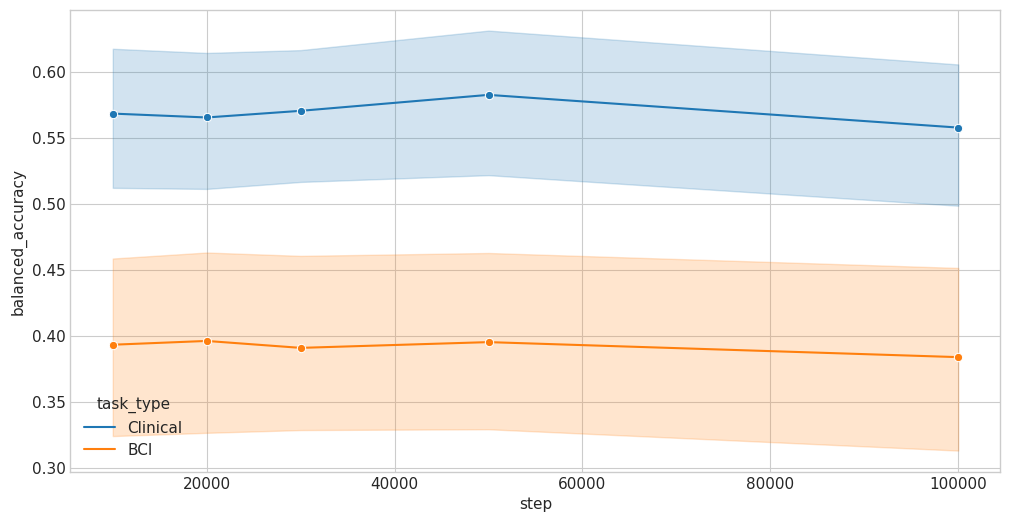

In [32]:
laya_b_og = df[df['model_display'] == 'LeJEPA_base_global_projv2_02sig_FULL_v0']
laya_b_og_v2 = df[df['model_display'] == 'LeJEPA_base_global_projv2_02sig_FULL_v2']

laya_b_og['step'] = laya_b_og['step'].str.replace('epoch_0_step_', '').str.replace('last', '50000').astype(int)
laya_b_og_v2['step'] = laya_b_og_v2['step'].str.replace('epoch_0_step_', '').str.replace('last', '100000').astype(int)

laya_b_og = pd.concat([laya_b_og, laya_b_og_v2], ignore_index=True)
# print(laya_b_og.groupby(['step', 'task_display']).size().min())
sns.lineplot(data=laya_b_og, x='step', y='balanced_accuracy', hue='task_type', marker='o')

In [33]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)

## Additional Experiments: Noise Robustness

All plots above use clean-only results. This section visualizes the noise sweeps.


In [ ]:
df_for_noiseplot = df_combined[(df_combined["percentage"] == 1.0)]
clean_baseline = df_for_noiseplot[df_for_noiseplot["is_clean"]].groupby("model_display")["balanced_accuracy"].mean()

In [ ]:
noise_to_plot  = df_for_noiseplot[~df_for_noiseplot["is_clean"]].sort_values("noise_snr_db", ascending=False)
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].fillna(noise_to_plot['noise_types'])
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].replace('gaussian+one_over_f+emg+channel_dropout', 'all')
noise_to_plot['model_display'] = noise_to_plot['model_display'].str.split('_noise').apply(lambda x: x[0])

In [ ]:
noise_to_plot['task_display'] = noise_to_plot['task_display'].str.replace('_clinical', '').str.replace('_', ' ').str.capitalize()

In [ ]:
for task in noise_to_plot['task'].unique():
    plt.figure(figsize=(10, 6))
    task_data = noise_to_plot[noise_to_plot['task'] == task]
    task_data = task_data[task_data['noise_types_str'] == 'all']
    task_data = task_data[~task_data['model_display'].str.contains('20')]
    task_data = task_data[task_data['noise_snr_db'] >= 0]
    sns.lineplot(
        data=task_data,
        x="noise_snr_db",
        y="balanced_accuracy",
        hue="model_display",
        hue_order=list(model_colors.keys()),
        palette=model_colors,
        marker="o"
    )
    plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)
    plt.title(f"{task_data['task_display'].iloc[0]}") #Noise Robustness on Task: 
    plt.xlabel("Noise SNR (dB)")
    plt.ylabel("Balanced Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Model", fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
noise_to_plot['task'].unique()

In [ ]:
#PAPER FIGURE!
sns.set_context('poster')
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=False, sharey=True)
for i, task in enumerate(['abnormal_clinical', 'epilepsy_clinical', 'parkinsons_clinical', 'seizure_clinical']):
    task_data = noise_to_plot[noise_to_plot['task'] == task]
    task_data = task_data[task_data['noise_types_str'] == 'all']
    task_data = task_data[~task_data['model_display'].str.contains('20')]
    task_data = task_data[task_data['noise_snr_db'] >= 0]
    ax = axes.flatten()[i]
    sns.lineplot(
        data=task_data,
        x="noise_snr_db",
        y="balanced_accuracy",
        hue="model_display",
        hue_order=list(model_colors.keys()),
        palette=model_colors,
        marker="o",
        ax=ax
    )
    ax.set_title(f"{task_data['task_display'].iloc[0]}") #Noise Robustness on Task: 
    ax.set_xlabel("Noise SNR (dB)")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_ylim(.2, 1)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(title="Model")
    else:
        ax.get_legend().remove()
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig("figures/noise_robustness_clinical_tasks.png", dpi=300, bbox_inches="tight")

In [ ]:
df_all['probe_type'].unique()

In [ ]:

#Show results for attentive probe
attentive = df_all[df_all['probe_type'] == 'attentive']
attentive = attentive[attentive['is_clean']]

attentive.groupby(['model_display', 'task'])['balanced_accuracy'].mean().sort_values(ascending=False)

In [ ]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

# Filter once
plot_df = noise_to_plot.copy()
plot_df = plot_df[~plot_df["model_display"].str.contains("20", na=False)]
plot_df = plot_df[plot_df["noise_snr_db"] >= 0]

for task, task_data in plot_df.groupby("task"):
    task_display = task_data["task_display"].iloc[0]
    noise_types = sorted(task_data["noise_types_str"].unique())
    #skip if not all models have not all noise types
    models_in_task = task_data["model_display"].unique()
    skip = False
    for model in models_in_task:
        model_data = task_data[task_data["model_display"] == model]
        model_noise_types = model_data["noise_types_str"].unique()
        if set(model_noise_types) != set(noise_types):
            skip = True
            break
    if skip:
        continue

    n = len(noise_types)
    cols = min(3, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharey=True, sharex=True)
    axes = axes.flatten() if n > 1 else [axes]

    for ax, nt in zip(axes, noise_types):
        sub = task_data[task_data["noise_types_str"] == nt]
        sns.lineplot(
            data=sub,
            x="noise_snr_db",
            y="balanced_accuracy",
            hue="model_display",
            hue_order=list(model_colors.keys()),
            palette=model_colors,
            marker="o",
            ax=ax
        )
        ax.invert_xaxis()
        ax.set_title(nt)
        ax.set_xlabel("Noise SNR (dB)")
        ax.set_ylabel("Balanced Accuracy")
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend().remove()

    # Remove empty axes if any
    for ax in axes[len(noise_types):]:
        ax.remove()

    # Single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(task_display, y=1.02)
    fig.tight_layout()
    plt.savefig(f"figures/noise/noise_robustness_{task}.png", dpi=300, bbox_inches="tight")
    plt.show()
